# Phase 3: Attendance Prediction using Regression Models
**Project:** Privacy-Preserving Synthetic Student Attendance Analysis and Prediction System

This notebook trains and evaluates regression models to predict student attendance percentage based on academic, personal, and behavioral factors.

### ⚠️ Data Leakage Warning
We must exclude `Classes_Attended` and `Total_Classes` from our predictor list. Because `Attendance_Percentage` is calculated directly using the formula:
$$\text{Attendance\_Percentage} = \frac{\text{Classes\_Attended}}{\text{Total\_Classes}} \times 100$$
including these variables would lead to direct data leakage, resulting in an artificial R2 score of 1.0. Our goal is to predict attendance using underlying student traits (like age, study hours, internal scores) to model student behavior rather than reproducing simple division arithmetic.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set style
sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
BASE_DIR = r"d:\Data_Science_attendence_project"
DATA_FILE = os.path.join(BASE_DIR, "data", "student_attendance_205_students.csv")
MODELS_DIR = os.path.join(BASE_DIR, "models")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")
CHARTS_DIR = os.path.join(OUTPUTS_DIR, "charts")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(CHARTS_DIR, exist_ok=True)

df = pd.read_csv(DATA_FILE)
print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")

Loaded dataset with 4100 rows and 21 columns.


In [3]:
target_col = 'Attendance_Percentage'

# Predictors we want to include
categorical_cols = ['Gender', 'Department', 'Year', 'Semester', 'Subject']
numeric_cols = [
    'Age',
    'Previous_Attendance_Percentage',
    'Assignment_Score',
    'Internal_Marks',
    'Study_Hours_Per_Week',
    'Medical_Leave_Days',
    'Travel_Distance_KM',
    'Previous_Exam_Score',
    'Late_Count',
    'Online_Class_Attendance'
]

all_predictors = categorical_cols + numeric_cols
X = df[all_predictors]
y = df[target_col]

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (4100, 15)
Target (y) shape: (4100,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 3280
Test size: 820


In [5]:
# Pipeline for categorical features
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Pipeline for numeric features
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Column transformer mapping columns to pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numeric_cols),
    ('cat', cat_transformer, categorical_cols)
])
print("Preprocessor built successfully.")

Preprocessor built successfully.


In [6]:
models = {
    'LinearRegression': LinearRegression(),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42, max_depth=8),
    'RandomForestRegressor': RandomForestRegressor(random_state=42, n_estimators=100, max_depth=12),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42, n_estimators=100, learning_rate=0.1)
}

results = []
trained_pipelines = {}

for name, model in models.items():
    # Create complete pipeline with preprocessing and model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    # Train model
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{name:25} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")
    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

LinearRegression          -> MAE: 9.3679, RMSE: 11.6108, R2: 0.6755
DecisionTreeRegressor     -> MAE: 10.2138, RMSE: 12.8313, R2: 0.6037


RandomForestRegressor     -> MAE: 9.1673, RMSE: 11.4357, R2: 0.6852


GradientBoostingRegressor -> MAE: 9.1786, RMSE: 11.3952, R2: 0.6874


In [7]:
results_df = pd.DataFrame(results)
results_csv_path = os.path.join(OUTPUTS_DIR, 'regression_model_results.csv')
results_df.to_csv(results_csv_path, index=False)
print("Saved results table.")
results_df

Saved results table.


,Model,MAE,MSE,RMSE,R2
0,LinearRegression,9.367864,134.810904,11.610810,0.675494
1,DecisionTreeRegressor,10.213813,164.642280,12.831301,0.603686
2,RandomForestRegressor,9.167304,130.776023,11.435734,0.685206
3,GradientBoostingRegressor,9.178561,129.850984,11.395218,0.687433


In [8]:
best_model_idx = results_df['RMSE'].idxmin()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_rmse = results_df.loc[best_model_idx, 'RMSE']
best_r2 = results_df.loc[best_model_idx, 'R2']

print(f"Best Model: {best_model_name} with RMSE of {best_rmse:.4f} and R2 of {best_r2:.4f}")

best_pipeline = trained_pipelines[best_model_name]
best_model_path = os.path.join(MODELS_DIR, 'best_regression_model.joblib')
joblib.dump(best_pipeline, best_model_path)
print(f"Saved pipeline to {best_model_path}")

Best Model: GradientBoostingRegressor with RMSE of 11.3952 and R2 of 0.6874
Saved pipeline to d:\Data_Science_attendence_project\models\best_regression_model.joblib


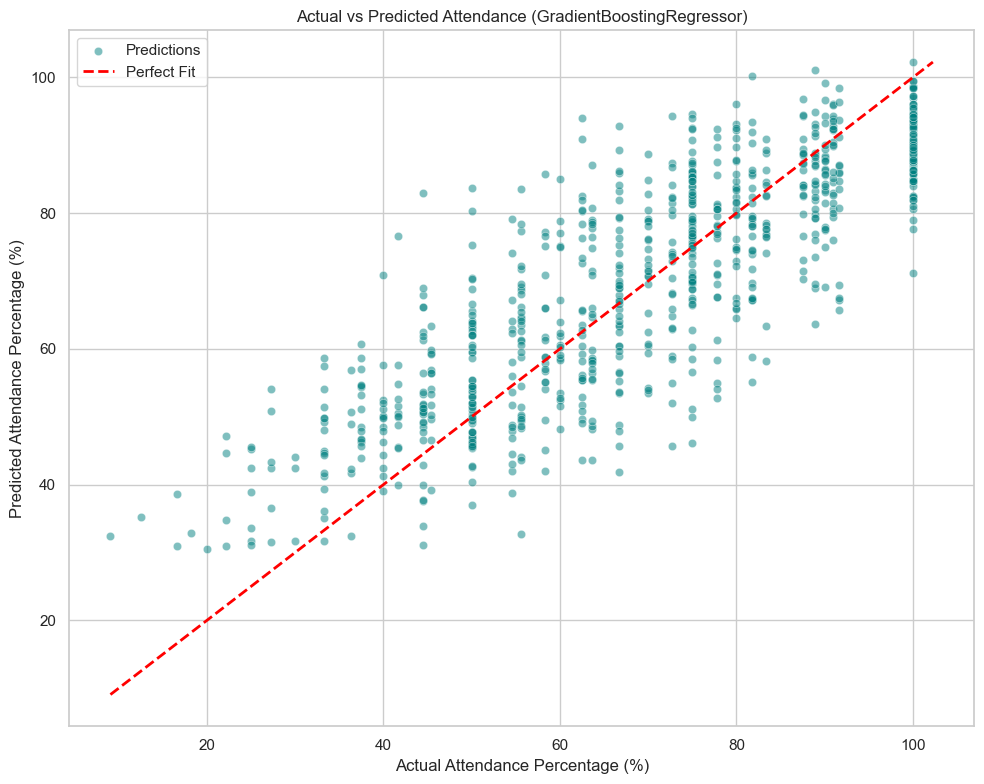

In [9]:
best_preds = best_pipeline.predict(X_test)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=best_preds, alpha=0.5, color='teal', label='Predictions')
min_val = min(y_test.min(), best_preds.min())
max_val = max(y_test.max(), best_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title(f"Actual vs Predicted Attendance ({best_model_name})")
plt.xlabel("Actual Attendance Percentage (%)")
plt.ylabel("Predicted Attendance Percentage (%)")
plt.legend()

chart_path = os.path.join(CHARTS_DIR, 'regression_actual_vs_predicted.png')
plt.tight_layout()
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()